ACTIVIDAD 1 - REDES NEURONALES BÁSICAS



importar librerias

In [7]:
import numpy as np
import matplotlib.pyplot as plt


DATASET (Compuerta AND)

In [3]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,0,0,1])

1. PERCEPTRÓN

In [8]:
class Perceptron:
    def __init__(self, input_size, lr=0.1, epochs=10):
        self.weights = np.zeros(input_size)
        self.bias = 0
        self.lr = lr
        self.epochs = epochs
        self.errors = []  # ← guarda los errores por época

    def activation(self, z):
        return 1 if z >= 0 else 0

    def predict(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.activation(z)

    def fit(self, X, y):
        for epoch in range(self.epochs):
            total_error = 0

            for i in range(len(X)):
                y_pred = self.predict(X[i])
                error = y[i] - y_pred

                total_error += abs(error)

                # Actualización de pesos
                self.weights += self.lr * error * X[i]
                self.bias += self.lr * error

            self.errors.append(total_error)  # guardar error de la época


2.RED NEURONAL DE UNA CAPA

In [9]:
class SingleLayerNN:
    def __init__(self, input_size, output_size):
        self.W = np.random.randn(input_size, output_size)
        self.b = np.zeros((1, output_size))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        z = np.dot(X, self.W) + self.b
        return self.sigmoid(z)

nn1 = SingleLayerNN(2,1)

print("\nSalida Red de una capa:")
print(nn1.forward(X))



Salida Red de una capa:
[[0.5       ]
 [0.17061355]
 [0.76844963]
 [0.40571512]]


3. RED NEURONAL MULTICAPA

In [10]:

class MultiLayerNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.zeros((1, output_size))

    def relu(self, z):
        return np.maximum(0, z)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        # Capa oculta
        z1 = np.dot(X, self.W1) + self.b1
        a1 = self.relu(z1)

        # Capa de salida
        z2 = np.dot(a1, self.W2) + self.b2
        a2 = self.sigmoid(z2)

        return a2

nn2 = MultiLayerNN(2,4,1)

print("\nSalida Red Multicapa:")
print(nn2.forward(X))


Salida Red Multicapa:
[[0.5       ]
 [0.4908177 ]
 [0.29872583]
 [0.48632773]]


Se grafica el error por época para observar cómo el modelo aprende

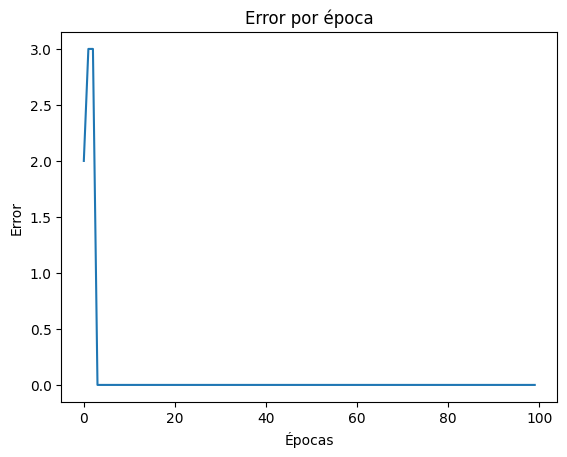

In [12]:
perceptron = Perceptron(input_size=2, lr=0.1, epochs=100)
perceptron.fit(X, y)

# Gráfica de error
plt.plot(perceptron.errors)
plt.title("Error por época")
plt.xlabel("Épocas")
plt.ylabel("Error")
plt.show()